# Construction Safety Intelligence · Notebook 2: Coding injury causes from the narrative
**Author:** Atul Iwale · **Project 14** · Real OSHA data (see notebook 1 for source, licence and cleaning)

**Task:** read the free-text narrative of a severe injury report and assign one of nine cause groups, the way an OSHA coder would. A contractor's own incident system rarely has trained coders, so an automatic, consistent first coding saves time and makes trend reporting possible.

**Truth labels:** OSHA's own event codes, grouped in notebook 1. They are human codes and not perfect, and the coding manual changed in January 2024.

**Contents**
1. Data and time split · 2. Baseline: keyword rules · 3. Classic NLP: TF-IDF with Naive Bayes, logistic regression and linear SVM
4. Neural networks: 1D-CNN and BiLSTM · 5. Results on the unseen test years · 6. The cost of the coding-manual change
7. What the model learned · 8. Error analysis · 9. Fall height: rule-based extraction · 10. Export for the app and for the LLM step

In [1]:
import os, re, json, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline, make_union
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
pd.set_option('display.width', 170); pd.set_option('display.max_colwidth', 150)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
SEED = 42; tf.keras.utils.set_random_seed(SEED); tf.config.experimental.enable_op_determinism()

I0000 00:00:1790238991.569906    1554 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790238992.969022    1554 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Data and time split
Reports with no usable cause ("Nonclassifiable", "Contact ... unspecified") are left out, because there is nothing to learn or test against. The split is by date: the model only ever sees the past.

In [2]:
d = pd.read_csv('../data/osha_construction_clean.csv', parse_dates=['event_date'])
d = d[d.cause_group != 'Unknown (not usable)'].reset_index(drop=True)
CLASSES = sorted(d.cause_group.unique())
tr, va, te = [d[d.split == s].reset_index(drop=True) for s in ['train', 'validation', 'test']]
pd.DataFrame({s: x.cause_group.value_counts() for s, x in zip(['train 2015-22', 'validation 2023', 'test 2024-25'], [tr, va, te])}).loc[d.cause_group.value_counts().index]

,train 2015-22,validation 2023,test 2024-25
cause_group,,,
Fall to lower level,5057,600,1149
Struck by or against object,3423,399,884
Caught in or crushed,1815,192,278
Vehicle or mobile equipment,1029,128,272
Electrical,693,80,186
"Slip, trip or same-level fall",649,65,167
Heat stress,449,51,105
"Fire, explosion or burn",365,42,90
Other,357,42,73


The classes are unbalanced: falls are 36% of reports, and "Fire, explosion or burn" about 3%. So the main score is **macro-F1**, which weighs every cause group equally, with accuracy alongside. A model that only predicted "Fall" would be 36% accurate but useless.

In [3]:
def text(x): return x.narrative.str.lower()
results = {}
def score(name, pred_te, pred_va=None):
    r = {'test accuracy': accuracy_score(te.cause_group, pred_te), 'test macro-F1': f1_score(te.cause_group, pred_te, average='macro')}
    if pred_va is not None: r['validation macro-F1 (2023)'] = f1_score(va.cause_group, pred_va, average='macro')
    results[name] = r; return pd.Series(r).round(3)

## 2. Baseline: keyword rules
The first thing a safety team would try is a keyword list. The rules below are checked in order, most specific first.

In [4]:
KEYWORDS = [
    ('Electrical', r'electr|shock|arc flash|volt|power line|energi[sz]ed'),
    ('Heat stress', r'heat (exhaustion|stroke|illness|cramps|related|rash)|dehydrat'),
    ('Fire, explosion or burn', r'burn|fire|explo|flash|ignit'),
    ('Fall to lower level', r'\bfell\b|\bfall'),
    ('Vehicle or mobile equipment', r'truck|vehicle|backed|backing|run over|forklift|overturn|rolled over'),
    ('Caught in or crushed', r'caught|pinned|crush|pinch|cave-in|collapse'),
    ('Struck by or against object', r'struck|\bhit\b|fell on|strike'),
    ('Slip, trip or same-level fall', r'slip|trip'),
]
def keyword_rule(t):
    for g, p in KEYWORDS:
        if re.search(p, t): return g
    return 'Other'
kw_te, kw_va = text(te).map(keyword_rule), text(va).map(keyword_rule)
score('Keyword rules (baseline)', kw_te, kw_va)

test accuracy                 0.551
test macro-F1                 0.495
validation macro-F1 (2023)    0.519
dtype: float64

Keywords reach about 55% accuracy. The problem is that narratives describe *sequences*: "he slipped on the ladder and fell 12 feet" contains both a slip and a fall, and "the load fell on his hand" contains "fell" but is a struck-by. Word order and combinations matter, which is what the models below learn.

## 3. Classic NLP: TF-IDF with Naive Bayes, logistic regression and linear SVM
**TF-IDF** turns each narrative into word and two-word-phrase weights, with less weight for words that appear everywhere ("employee", "the"). A second variant adds **character n-grams** (3–5 letters), which cope with typos and word forms ("amputat", "electroc"). Each model's main setting is tuned on the 2023 validation year, never on the test years.

In [5]:
def words(): return TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
def words_chars(): return make_union(words(), TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, sublinear_tf=True, max_features=150000))
def tune(make, grid, name):
    best = None
    for g in grid:
        m = make(g).fit(text(tr), tr.cause_group); f = f1_score(va.cause_group, m.predict(text(va)), average='macro')
        if best is None or f > best[0]: best = (f, g, m)
    print(f'{name:45s} best setting {best[1]:<6} validation macro-F1 {best[0]:.3f}')
    return best[2]
nb   = tune(lambda a: make_pipeline(words(), ComplementNB(alpha=a)), [0.1, 0.3, 1.0], 'Naive Bayes (words)')
lr   = tune(lambda c: make_pipeline(words(), LogisticRegression(C=c, max_iter=4000)), [2, 8, 32], 'Logistic regression (words)')
lrc  = tune(lambda c: make_pipeline(words_chars(), LogisticRegression(C=c, max_iter=4000)), [2, 8, 32], 'Logistic regression (words + characters)')
svm  = tune(lambda c: make_pipeline(words_chars(), LinearSVC(C=c)), [0.1, 0.5, 2], 'Linear SVM (words + characters)')
for name, m in [('Naive Bayes', nb), ('Logistic regression (words)', lr), ('Logistic regression (words + characters)', lrc), ('Linear SVM (words + characters)', svm)]:
    score(name, m.predict(text(te)), m.predict(text(va)))
pd.DataFrame(results).T.round(3)

Naive Bayes (words)                           best setting 0.3    validation macro-F1 0.789


Logistic regression (words)                   best setting 32     validation macro-F1 0.859


Logistic regression (words + characters)      best setting 8      validation macro-F1 0.876


Linear SVM (words + characters)               best setting 0.5    validation macro-F1 0.869


,test accuracy,test macro-F1,validation macro-F1 (2023)
Keyword rules (baseline),0.551,0.495,0.519
Naive Bayes,0.787,0.758,0.789
Logistic regression (words),0.838,0.832,0.859
Logistic regression (words + characters),0.838,0.837,0.876
Linear SVM (words + characters),0.839,0.840,0.869


## 4. Neural networks: 1D-CNN and BiLSTM
Both learn their own word embeddings (64 numbers per word) from the training narratives.
- **1D-CNN:** 128 filters slide over three-word windows and keep the strongest match, acting as learned phrase detectors ("fell from ladder", "caught his hand").
- **BiLSTM:** reads the narrative word by word in both directions, carrying context along the sentence.

Training stops when the 2023 validation loss stops improving.

In [6]:
tok = lambda t: re.findall(r'[a-z]+|\d+', t.lower())
counts = Counter(w for t in tr.narrative for w in tok(t))
VOCAB = ['<pad>', '<unk>'] + [w for w, c in counts.most_common() if c >= 3]; IDX = {w: i for i, w in enumerate(VOCAB)}
SEQ = 120
def encode(series):
    a = np.zeros((len(series), SEQ), dtype='int32')
    for i, t in enumerate(series):
        ids = [IDX.get(w, 1) for w in tok(t)][:SEQ]; a[i, :len(ids)] = ids
    return a
ci = {c: i for i, c in enumerate(CLASSES)}
Xtr, Xva, Xte = encode(tr.narrative), encode(va.narrative), encode(te.narrative)
ytr, yva = tr.cause_group.map(ci).values, va.cause_group.map(ci).values
print(f'Vocabulary: {len(VOCAB):,} words seen at least 3 times; narratives cut at {SEQ} words (covers {np.mean([len(tok(t)) <= SEQ for t in tr.narrative]):.1%} in full)')

def build(kind):
    inp = tf.keras.Input((SEQ,)); x = tf.keras.layers.Embedding(len(VOCAB), 64)(inp); x = tf.keras.layers.SpatialDropout1D(0.2)(x)
    if kind == 'cnn': x = tf.keras.layers.Conv1D(128, 3, activation='relu')(x); x = tf.keras.layers.GlobalMaxPooling1D()(x)
    else: x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(48))(x)
    x = tf.keras.layers.Dropout(0.4)(x); x = tf.keras.layers.Dense(64, activation='relu')(x)
    m = tf.keras.Model(inp, tf.keras.layers.Dense(len(CLASSES), activation='softmax')(x))
    m.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy']); return m
nets = {}
for kind, name in [('cnn', '1D-CNN (neural network)'), ('lstm', 'BiLSTM (neural network)')]:
    m = build(kind)
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=15, batch_size=64, verbose=0,
              callbacks=[tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True, monitor='val_loss')])
    nets[name] = m
    print(f'{name}: stopped after {len(h.history["loss"])} epochs')
    score(name, [CLASSES[i] for i in m.predict(Xte, verbose=0).argmax(1)], [CLASSES[i] for i in m.predict(Xva, verbose=0).argmax(1)])

Vocabulary: 3,923 words seen at least 3 times; narratives cut at 120 words (covers 99.7% in full)


1D-CNN (neural network): stopped after 7 epochs


BiLSTM (neural network): stopped after 9 epochs


## 5. Results on the unseen test years (2024 – Nov 2025)

In [7]:
res = pd.DataFrame(results).T.sort_values('test macro-F1', ascending=False).round(3); res

,test accuracy,test macro-F1,validation macro-F1 (2023)
Linear SVM (words + characters),0.839,0.840,0.869
Logistic regression (words + characters),0.838,0.837,0.876
Logistic regression (words),0.838,0.832,0.859
1D-CNN (neural network),0.834,0.818,0.851
Naive Bayes,0.787,0.758,0.789
BiLSTM (neural network),0.787,0.752,0.787
Keyword rules (baseline),0.551,0.495,0.519


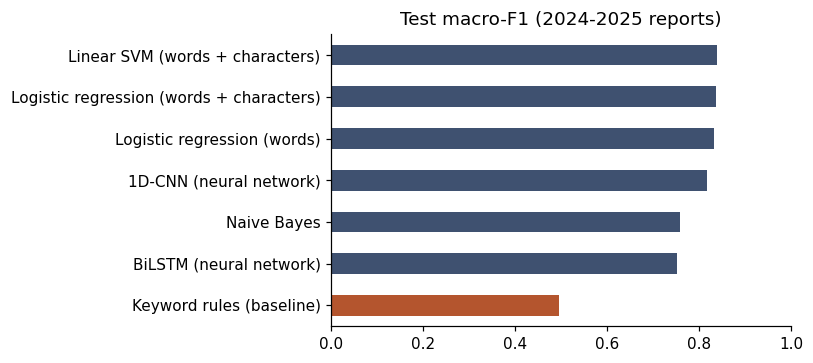

In [8]:
ax = res['test macro-F1'].sort_values().plot.barh(color=['#B4552E' if 'baseline' in i else '#3F5170' for i in res['test macro-F1'].sort_values().index], figsize=(7.5, 3.4))
ax.set_xlim(0, 1); ax.set_title('Test macro-F1 (2024-2025 reports)'); ax.set_ylabel(''); plt.tight_layout(); plt.show()

**Reading the results**
- Every model beats the keyword list by a wide margin. The best classic models are about 30 points of accuracy above it.
- The **linear models win**. Logistic regression and the linear SVM on TF-IDF beat both neural networks. Narratives are short (median 190 characters), and 14,000 training examples is small for a network that has to learn its own word meanings. In Project 5, where the risk sat in exact legal phrases, the CNN won. Here, the right *words* carry most of the signal, and a linear model captures them with less data.
- The **BiLSTM** is the weakest model apart from the baseline. It has the most parameters and the least data per parameter.
- **Choice for the app:** logistic regression on words. It is within about a point of the best model, and it is fully explainable: every word has a weight per cause, so the app can show exactly which words drove each prediction. It is also small enough to run in a browser.

In [9]:
APP = lr
pred = APP.predict(text(te))
print(classification_report(te.cause_group, pred, digits=3))

                               precision    recall  f1-score   support

         Caught in or crushed      0.488     0.737     0.587       278
                   Electrical      0.968     0.984     0.976       186
          Fall to lower level      0.915     0.970     0.941      1149
      Fire, explosion or burn      0.952     0.889     0.920        90
                  Heat stress      1.000     1.000     1.000       105
                        Other      1.000     0.616     0.763        73
Slip, trip or same-level fall      0.847     0.695     0.763       167
  Struck by or against object      0.824     0.736     0.778       884
  Vehicle or mobile equipment      0.856     0.680     0.758       272

                     accuracy                          0.838      3204
                    macro avg      0.872     0.812     0.832      3204
                 weighted avg      0.853     0.838     0.840      3204



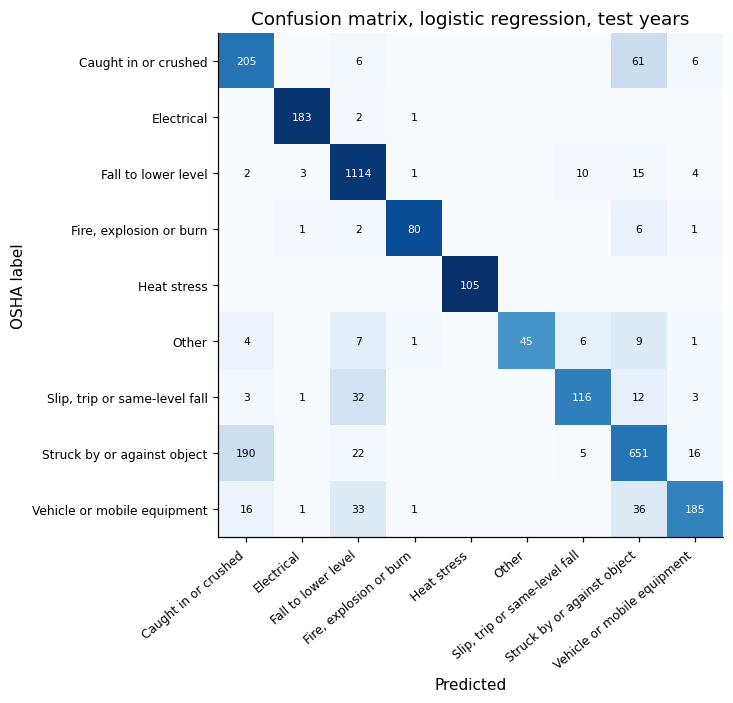

In [10]:
cm = pd.DataFrame(confusion_matrix(te.cause_group, pred, labels=CLASSES), index=CLASSES, columns=CLASSES)
fig, ax = plt.subplots(figsize=(8.5, 6.5)); im = ax.imshow(cm.div(cm.sum(1), axis=0), cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=40, ha='right', fontsize=8); ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES, fontsize=8)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if cm.iat[i, j]: ax.text(j, i, cm.iat[i, j], ha='center', va='center', fontsize=7, color='white' if cm.iat[i, j] / cm.iloc[i].sum() > .5 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('OSHA label'); ax.set_title('Confusion matrix, logistic regression, test years'); plt.tight_layout(); plt.show()

Electrical, heat, falls and fire are coded almost perfectly: their narratives use distinctive words. The hard boundary is **caught-in versus struck-by**, and that is exactly the boundary OSHA redrew in 2024.

## 6. The cost of the coding-manual change
Notebook 1 showed that OSHA's coders began using new titles in January 2024. Does the model drop because the narratives changed, or because the labels changed?

In [11]:
va_f1 = f1_score(va.cause_group, APP.predict(text(va)), average=None, labels=CLASSES)
te_f1 = f1_score(te.cause_group, pred, average=None, labels=CLASSES)
drift = pd.DataFrame({'F1 on 2023 (old manual)': va_f1, 'F1 on 2024-25 (new manual)': te_f1}, index=CLASSES)
drift['change'] = drift.iloc[:, 1] - drift.iloc[:, 0]; drift.sort_values('change').round(3)

,F1 on 2023 (old manual),F1 on 2024-25 (new manual),change
Caught in or crushed,0.779,0.587,-0.191
Struck by or against object,0.857,0.778,-0.079
Vehicle or mobile equipment,0.807,0.758,-0.049
Other,0.789,0.763,-0.026
Heat stress,1.000,1.000,0.000
Fall to lower level,0.941,0.941,0.001
"Fire, explosion or burn",0.918,0.920,0.002
Electrical,0.949,0.976,0.027
"Slip, trip or same-level fall",0.696,0.763,0.068


In [12]:
# Experiment: add the first year of new-manual reports to training, and test on 2025 only.
t24, t25 = te[te.event_date.dt.year == 2024], te[te.event_date.dt.year == 2025]
old_only = make_pipeline(words(), LogisticRegression(C=APP[-1].C, max_iter=4000)).fit(text(pd.concat([tr, va])), pd.concat([tr, va]).cause_group)
with_2024 = make_pipeline(words(), LogisticRegression(C=APP[-1].C, max_iter=4000)).fit(text(pd.concat([tr, va, t24])), pd.concat([tr, va, t24]).cause_group)
cmp = pd.DataFrame({
    'trained 2015-2023 (old manual only)': [accuracy_score(t25.cause_group, old_only.predict(text(t25))), f1_score(t25.cause_group, old_only.predict(text(t25)), average='macro'),
                                            f1_score(t25.cause_group, old_only.predict(text(t25)), average=None, labels=['Caught in or crushed'])[0]],
    'trained 2015-2024 (adds a year of new manual)': [accuracy_score(t25.cause_group, with_2024.predict(text(t25))), f1_score(t25.cause_group, with_2024.predict(text(t25)), average='macro'),
                                                     f1_score(t25.cause_group, with_2024.predict(text(t25)), average=None, labels=['Caught in or crushed'])[0]]},
    index=['2025 accuracy', '2025 macro-F1', '2025 F1, caught in or crushed'])
def on_2025(m): p = m.predict(text(t25)); return [accuracy_score(t25.cause_group, p), f1_score(t25.cause_group, p, average='macro'), f1_score(t25.cause_group, p, average=None, labels=['Caught in or crushed'])[0]]
both = pd.concat([tr, va, t24])
for w in [3, 6, 10]:   # give the 2024 (new-manual) reports more weight
    sw = np.r_[np.ones(len(tr) + len(va)), np.full(len(t24), w)]
    m = make_pipeline(words(), LogisticRegression(C=APP[-1].C, max_iter=4000)).fit(text(both), both.cause_group, logisticregression__sample_weight=sw)
    cmp[f'2015-2024, 2024 weighted x{w}'] = on_2025(m)
cmp['trained on 2024 only'] = on_2025(make_pipeline(words(), LogisticRegression(C=APP[-1].C, max_iter=4000)).fit(text(t24), t24.cause_group))
cmp.T.round(3)

,2025 accuracy,2025 macro-F1,"2025 F1, caught in or crushed"
trained 2015-2023 (old manual only),0.843,0.844,0.610
trained 2015-2024 (adds a year of new manual),0.845,0.843,0.606
"2015-2024, 2024 weighted x3",0.847,0.844,0.613
"2015-2024, 2024 weighted x6",0.845,0.840,0.607
"2015-2024, 2024 weighted x10",0.847,0.841,0.604
trained on 2024 only,0.782,0.697,0.376


The drop is concentrated in **caught-in or crushed** (F1 down about 0.19) and, less so, struck-by: exactly the two groups whose codes OSHA redrew. Falls, heat, fire and electrical, whose definitions did not change, hold steady. The narratives didn't change; the labels did.

**Retraining did not fix it.** Adding the 2024 reports to training leaves 2025 almost unchanged, and I also tried giving 2024 reports 3, 6 and 10 times the weight, with the same result. A model trained on 2024 alone is far worse (macro-F1 about 0.70), so the eight years of old-manual data are still worth keeping. The honest conclusion: under the new manual, the line between "caught between" and "struck by" depends on details that many narratives don't state, so part of this error is not recoverable from the text. In a real deployment I'd monitor accuracy by cause group every month, and treat these two groups as one "contact with objects" group in trend reports until more new-manual data exists.

## 7. What the model learned
The logistic regression weights show which words push a narrative towards each cause. These are what the app highlights.

In [13]:
vec, clf = APP[0], APP[-1]; vocab = np.array(vec.get_feature_names_out())
top = {c: ', '.join(vocab[np.argsort(clf.coef_[i])[::-1][:10]]) for i, c in enumerate(clf.classes_)}
pd.Series(top).to_frame('strongest words and phrases')

,strongest words and phrases
Caught in or crushed,"finger, between, collapsed, machine, pinched, caught, shifted, amputation, pulled, trench"
Electrical,"shocked, electrical, burns, shock, was shocked, energized, flash, arc, power, electric"
Fall to lower level,"fell, feet, ladder, employee fell, he fell, and fell, off, fell from, fell through, roof"
"Fire, explosion or burn","fire, burns, hot, exploded, ignited, burned, burning, gas, explosion, burns to"
Heat stress,"heat, dehydration, cramps, exhaustion, heat exhaustion, cramping, became, heat stress, stress, due"
Other,"chemical, chemical burns, bitten, hernia, carbon, was bitten, carbon monoxide, monoxide, altercation, lifting"
"Slip, trip or same-level fall","tripped, fell, slipped, employee fell, fall, slipped on, and fell, employee slipped, tripped over, fell and"
Struck by or against object,"fell on, struck, saw, striking, dropped, pressure, it fell, lacerated, hammer, employee the"
Vehicle or mobile equipment,"forklift, barge, truck, vehicle, struck, backed, driving, ran, over, was driving"


The words make sense to a safety professional: "heat exhaustion" and "dehydration" for heat; "amputated", "caught" and "pinched" for caught-in; "backing" and "struck by truck" for vehicles. The model has learned the vocabulary of site incidents, not quirks of the data.

## 8. Error analysis
Reading the mistakes shows whether the model is wrong, or whether the label is debatable.

In [14]:
err = te.assign(pred=pred)[lambda x: x.pred != x.cause_group]
print(f'{len(err)} of {len(te)} test reports misclassified ({len(err)/len(te):.1%}). Most common confusions:')
print(err.groupby(['cause_group', 'pred']).size().sort_values(ascending=False).head(6).to_string())
for _, r in err[(err.cause_group == 'Caught in or crushed') & (err.pred == 'Struck by or against object')].head(3).iterrows():
    print(f'\nOSHA: {r.cause_group} ({r.event_title}) | model: {r.pred}\n  {r.narrative[:300]}')

520 of 3204 test reports misclassified (16.2%). Most common confusions:
cause_group                    pred                       
Struck by or against object    Caught in or crushed           190
Caught in or crushed           Struck by or against object     61
Vehicle or mobile equipment    Struck by or against object     36
                               Fall to lower level             33
Slip, trip or same-level fall  Fall to lower level             32
Struck by or against object    Fall to lower level             22

OSHA: Caught in or crushed (Caught, entangled in running powered equipment normal operation) | model: Struck by or against object
  An employee was using a table saw when they suffered amputations to several fingers.

OSHA: Caught in or crushed (Caught, entangled in running powered equipment normal operation) | model: Struck by or against object
  An employee was retrieving rigging straps to begin rigging a stack of wooden and concrete forms to be lifted via an excava

Most errors sit on the struck-by / caught-in line. Several are honest disagreements: a bucket landing on a foot is "compressed between running equipment and other object" to the OSHA coder and "struck by" to the model, and a human second opinion would split on it. That is useful for the business case: where the model is wrong, the report is often ambiguous too.

## 9. Fall height: rule-based extraction
For falls, the height matters more than the cause: fall protection rules and the severity of injuries change with height. OSHA's title gives a height band for about half of all falls. Here is how far simple rules get at pulling the height out of the narrative. Notebook 3 compares this with an LLM.

In [15]:
NUM = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10, 'eleven': 11, 'twelve': 12,
       'thirteen': 13, 'fourteen': 14, 'fifteen': 15, 'sixteen': 16, 'seventeen': 17, 'eighteen': 18, 'nineteen': 19, 'twenty': 20, 'thirty': 30, 'forty': 40, 'fifty': 50}
HEIGHT = re.compile(r"(\d+(?:\.\d+)?|" + '|'.join(sorted(NUM, key=len, reverse=True)) + r")(?:\s*(?:-|to)\s*\d+)?\s*(?:-\s*)?(?:feet|foot|ft\b|')", re.I)
def rule_height(t):
    '''First height in feet mentioned in the narrative, or None.'''
    m = HEIGHT.search(t)
    if not m: return None
    v = m.group(1).lower(); return float(NUM.get(v, v)) if v in NUM or re.match(r'\d', v) else None
def band(ft):
    if ft is None or pd.isna(ft): return ''
    for lim, b in [(6, 'Under 6 ft'), (11, '6-10 ft'), (16, '11-15 ft'), (21, '16-20 ft'), (26, '21-25 ft'), (31, '26-30 ft')]:
        if ft < lim: return b
    return 'Over 30 ft'
falls_te = te[(te.cause_group == 'Fall to lower level') & te.fall_band_osha.notna()].copy()
falls_te['rule_ft'] = falls_te.narrative.map(rule_height); falls_te['rule_band'] = falls_te.rule_ft.map(band)
found = falls_te.rule_band != ''
print(f'Test falls with an OSHA height band: {len(falls_te)}')
print(f'Rules found a height in {found.mean():.1%} of them; band matches OSHA in {(falls_te.rule_band == falls_te.fall_band_osha)[found].mean():.1%} of those found')
print(f'Overall band agreement (missing counts as wrong): {(falls_te.rule_band == falls_te.fall_band_osha).mean():.1%}')

Test falls with an OSHA height band: 196
Rules found a height in 78.1% of them; band matches OSHA in 75.8% of those found
Overall band agreement (missing counts as wrong): 59.2%


The rules find a height in most narratives, but they take the *first* height mentioned, which is sometimes the height of the ladder, the wall or the trench rather than the fall itself. Deciding which number is the fall height needs an understanding of the sentence, which is where an LLM can help.

## 10. Export for the app and for the LLM step
The app runs the logistic regression in the browser. The export holds the vocabulary, IDF weights, class weights, a set of test narratives with Python's own probabilities (so the app can check it gets the same answer), and the summary tables for the dashboard.

The LLM step (notebook 3) gets **only the report ID and narrative** of each test report, never the OSHA label, so the LLM is tested blind.

In [16]:
full = pd.read_csv('../data/osha_construction_clean.csv', parse_dates=['event_date'])
known = full[full.cause_group != 'Unknown (not usable)']
check_rows = te.iloc[::80]
proba = APP.predict_proba(text(check_rows))
r6 = lambda a: [round(float(v), 6) for v in a]
risk = known.groupby('cause_group').agg(reports=('report_id', 'size'), amputation=('amputations', lambda s: round(float((s > 0).mean()), 4))).reset_index()
trade = pd.crosstab(known.trade, known.cause_group).reset_index().to_dict(orient='records')
yearly = pd.crosstab(known.event_date.dt.year, known.cause_group).reset_index().rename(columns={'event_date': 'year'}).to_dict(orient='records')
examples = te.assign(pred=pred).groupby('cause_group').head(4)[['report_id', 'event_date', 'trade', 'state', 'cause_group', 'event_title', 'narrative']]
export = {
    'classes': list(clf.classes_), 'vocab': vocab.tolist(), 'idf': r6(vec.idf_), 'coef': [r6(row) for row in clf.coef_], 'intercept': r6(clf.intercept_),
    'results': res.reset_index().rename(columns={'index': 'model'}).to_dict(orient='records'),
    'report': pd.DataFrame(classification_report(te.cause_group, pred, output_dict=True)).T.round(3).reset_index().rename(columns={'index': 'label'}).to_dict(orient='records'),
    'drift': drift.round(3).reset_index().rename(columns={'index': 'cause_group'}).to_dict(orient='records'),
    'risk': risk.to_dict(orient='records'), 'trade': trade, 'yearly': yearly,
    'examples': examples.assign(event_date=examples.event_date.dt.strftime('%Y-%m-%d')).to_dict(orient='records'),
    'check': [{'text': t, 'proba': r6(p)} for t, p in zip(check_rows.narrative, proba)],
    'n': {'reports': int(len(full)), 'train': int(len(tr)), 'validation': int(len(va)), 'test': int(len(te))},
}
with open('../model/safety_model_export.json', 'w') as f: json.dump(export, f, separators=(',', ':'))
print(f"Exported: {len(export['vocab']):,} terms x {len(export['classes'])} classes, {os.path.getsize('../model/safety_model_export.json')/1e6:.1f} MB")

te[['report_id', 'narrative']].to_csv('../data/llm_input_test.csv', index=False)
te.assign(model_pred=pred, rule_ft=te.narrative.map(rule_height))[['report_id', 'cause_group', 'event_title', 'fall_band_osha', 'model_pred', 'rule_ft']].to_csv('../data/test_labels_and_classic_predictions.csv', index=False)
print(f'LLM input: {len(te):,} test narratives (ID and text only) -> data/llm_input_test.csv')

Exported: 33,617 terms x 9 classes, 3.7 MB
LLM input: 3,204 test narratives (ID and text only) -> data/llm_input_test.csv


## Summary
- **Task:** code the cause of a construction injury from its narrative, trained on 2015–2022 OSHA reports and tested on 2024–2025.
- **Result:** logistic regression and a linear SVM on TF-IDF reach about **84% accuracy and 0.83–0.84 macro-F1**, against 55% and 0.50 for a keyword list. The 1D-CNN (0.82) and BiLSTM (0.75) do worse: short narratives and 14,000 examples favour linear models.
- **Real-world lesson:** OSHA's 2024 coding-manual change costs accuracy on the redefined caught-in group. It was measured and explained; retraining with a year of new-manual reports did not recover it, so it is reported as a known limit.
- **Explainability:** the chosen model's word weights read like a safety manager's vocabulary, and the app shows them for every prediction.
- **Next:** notebook 3 compares an OpenAI model on the same test reports, blind, and uses it to extract the fall height, equipment and task.